In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('/content/SeoulBikeData.csv', encoding='latin1')

df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [4]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [6]:
df.isnull().sum()

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
print(df['Seasons'].unique())
print(df['Holiday'].unique())
print(df['Functioning Day'].unique())
print(df['Seasons'].value_counts())
print(df['Holiday'].value_counts())
print(df['Functioning Day'].value_counts())

['Winter' 'Spring' 'Summer' 'Autumn']
['No Holiday' 'Holiday']
['Yes' 'No']
Seasons
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64
Holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64
Functioning Day
Yes    8465
No      295
Name: count, dtype: int64


In [9]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    print("\n", column)
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())


 Rented Bike Count
Minimum: 0
Maximum: 3556

 Hour
Minimum: 0
Maximum: 23

 Temperature(°C)
Minimum: -17.8
Maximum: 39.4

 Humidity(%)
Minimum: 0
Maximum: 98

 Wind speed (m/s)
Minimum: 0.0
Maximum: 7.4

 Visibility (10m)
Minimum: 27
Maximum: 2000

 Dew point temperature(°C)
Minimum: -30.6
Maximum: 27.2

 Solar Radiation (MJ/m2)
Minimum: 0.0
Maximum: 3.52

 Rainfall(mm)
Minimum: 0.0
Maximum: 35.0

 Snowfall (cm)
Minimum: 0.0
Maximum: 8.8


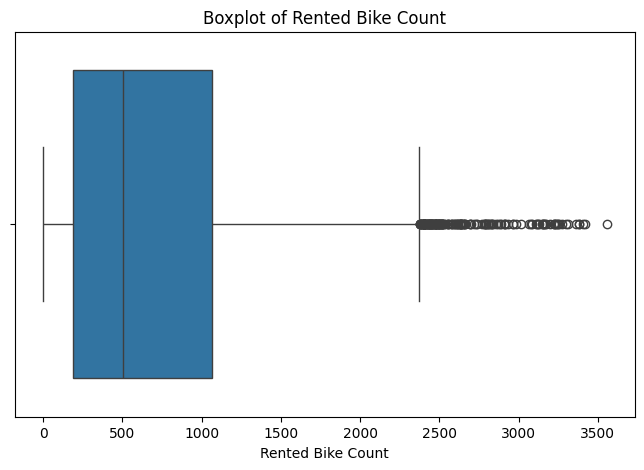

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Rented Bike Count'])
plt.title('Boxplot of Rented Bike Count')
plt.show()

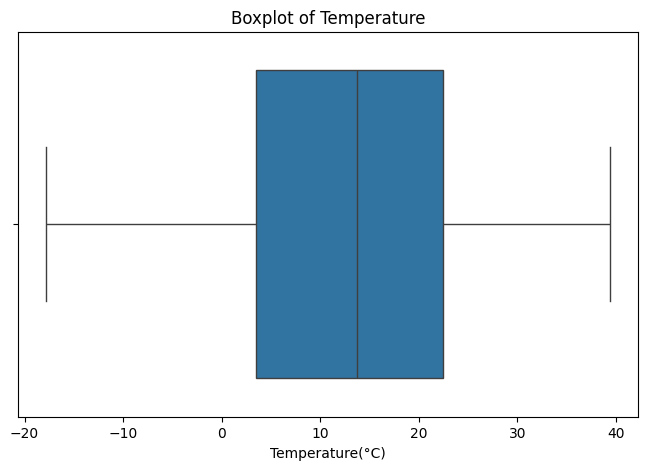

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Temperature(°C)'])
plt.title('Boxplot of Temperature')
plt.show()

In [12]:
df['Date'].dtype

dtype('O')

In [13]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

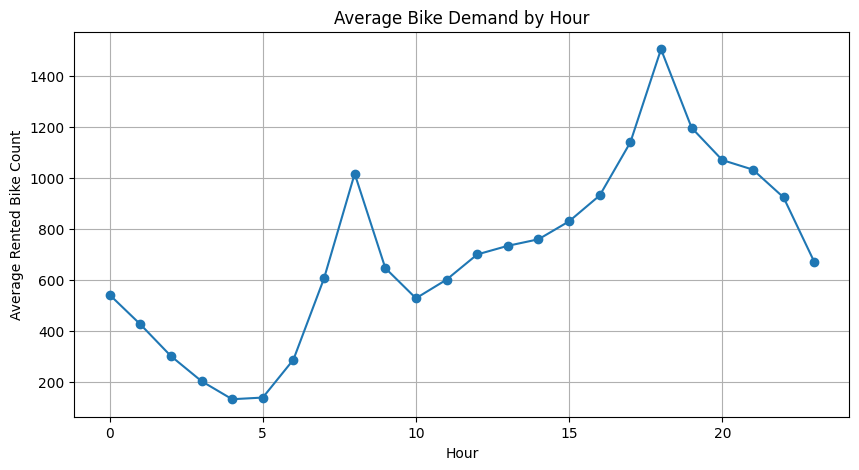

In [14]:
hourly_demand = df.groupby('Hour')['Rented Bike Count'].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_demand.index, hourly_demand.values, marker='o')
plt.xlabel('Hour')
plt.ylabel('Average Rented Bike Count')
plt.title('Average Bike Demand by Hour')
plt.grid()
plt.show()

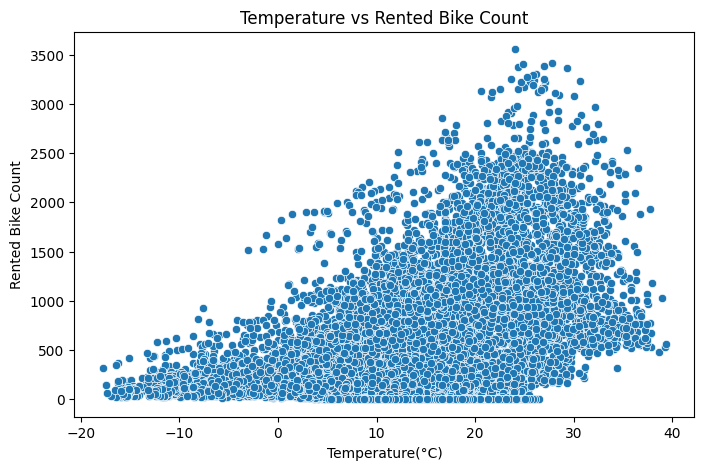

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='Temperature(°C)',
    y='Rented Bike Count',
    data=df
)

plt.title('Temperature vs Rented Bike Count')
plt.show()

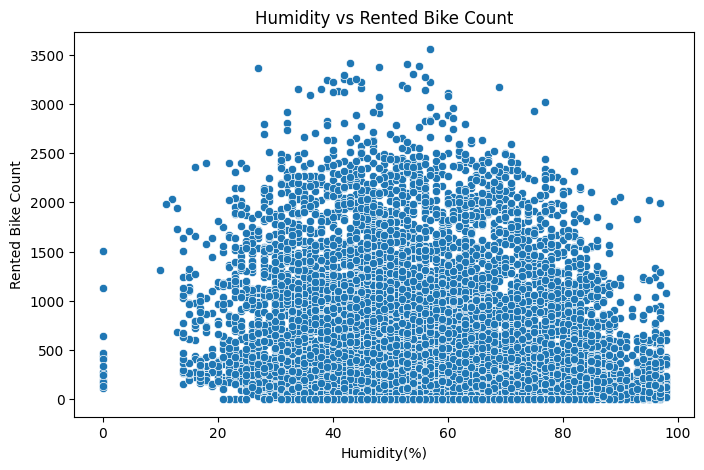

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='Humidity(%)',
    y='Rented Bike Count',
    data=df
)

plt.title('Humidity vs Rented Bike Count')
plt.show()

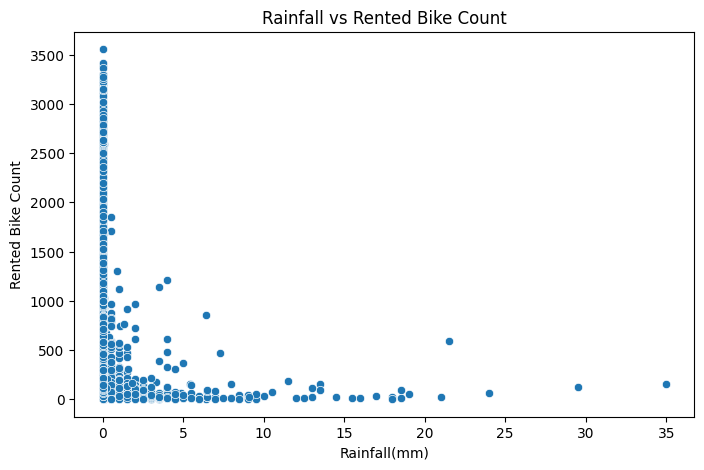

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='Rainfall(mm)',
    y='Rented Bike Count',
    data=df
)

plt.title('Rainfall vs Rented Bike Count')
plt.show()

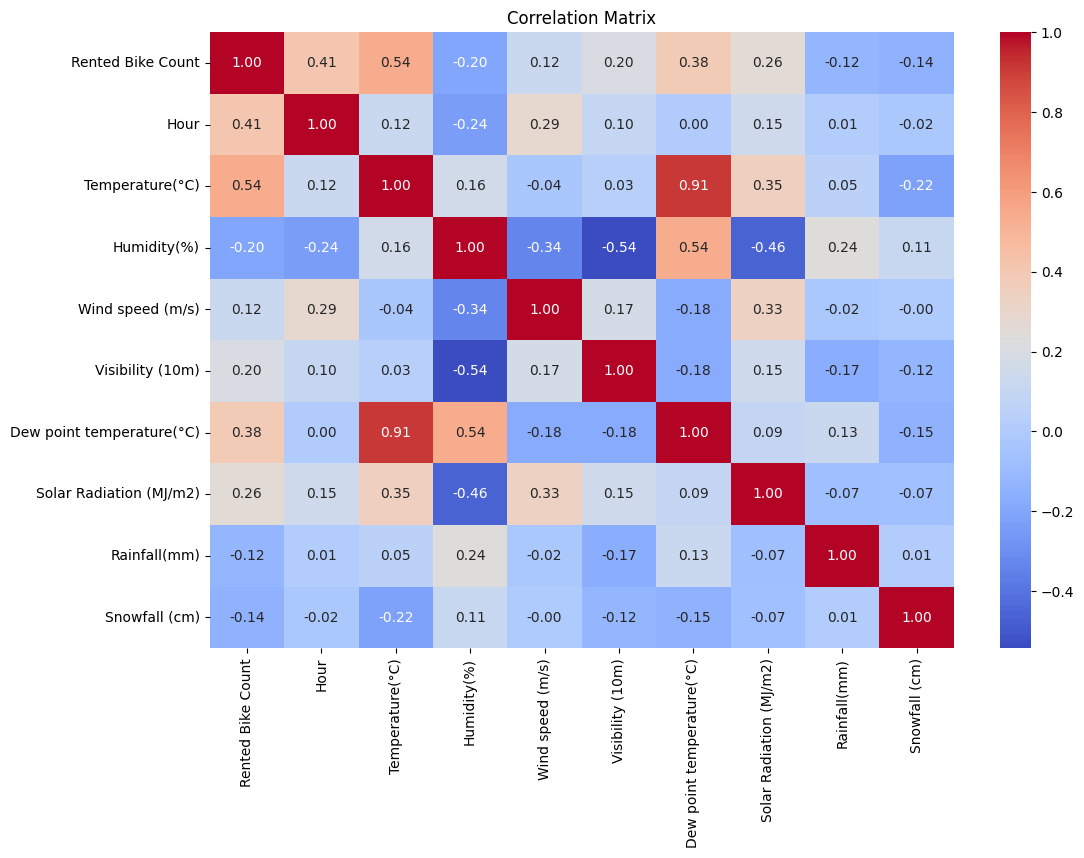

In [18]:
correlation = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

Cleaning The Dataset from below

In [20]:
#Cleaning the dataset
df_slr = df[df['Functioning Day'] == 'Yes'].copy()

print("Original dataset:", df.shape)
print("Dataset for regression:", df_slr.shape)

Original dataset: (8760, 14)
Dataset for regression: (8465, 14)


In [21]:
print(df_slr['Rented Bike Count'].describe())

count    8465.000000
mean      729.156999
std       642.351166
min         2.000000
25%       214.000000
50%       542.000000
75%      1084.000000
max      3556.000000
Name: Rented Bike Count, dtype: float64


Simple Linear Regression Model
X - Independent variable
y - dependent variable

In [22]:
#Select X and y
X = df_slr[['Temperature(°C)']]
y = df_slr['Rented Bike Count']

In [23]:
#Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 6772
Testing samples: 1693


In [24]:
#Create the Linear Regression model
model = LinearRegression()

In [25]:
#Train the model
model.fit(X_train, y_train)

LinearRegression()

In [26]:
#equation
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 346.61897785338726
Coefficient: 30.077098499036296


In [27]:
print(
    f"Equation: Rented Bike Count = "
    f"{model.intercept_:.2f} + "
    f"({model.coef_[0]:.2f} × Temperature)"
)

Equation: Rented Bike Count = 346.62 + (30.08 × Temperature)


In [28]:
#predictions on test data
y_predict = model.predict(X_test)

In [30]:
comparison = pd.DataFrame({
    'Temperature': X_test['Temperature(°C)'],
    'Actual Bike Count': y_test,
    'Predicted Bike Count': y_predict
})

comparison.head(10)

,Temperature,Actual Bike Count,Predicted Bike Count
5993,35.6,1232,1417.363684
5340,28.1,964,1191.785446
5951,28.8,942,1212.839415
879,2.3,373,415.796304
6909,24.7,1259,1089.523311
5771,33.6,476,1357.209487
4933,30.6,1062,1266.978192
1452,-3.2,253,250.372263
7314,16.6,2857,845.898813
8465,8.7,1039,608.289735


In [31]:
#evaluate the model
mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_predict)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 381.238502216127
Mean Squared Error (MSE): 265041.95053837827
Root Mean Squared Error (RMSE): 514.8222514017613
R² Score: 0.32488243123316574


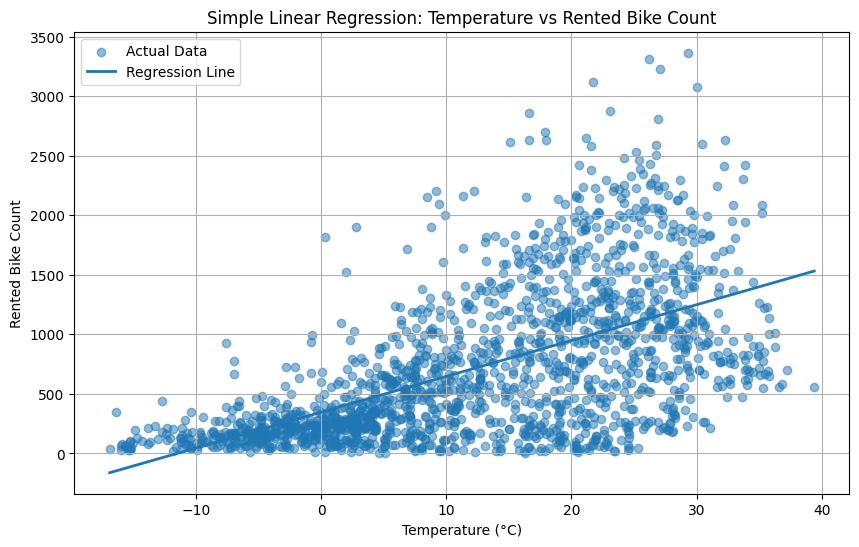

In [32]:
plot_data = pd.DataFrame({
    'Temperature': X_test['Temperature(°C)'],
    'Actual': y_test,
    'Predicted': y_predict
}).sort_values('Temperature')

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data['Temperature'],
    plot_data['Actual'],
    alpha=0.5,
    label='Actual Data'
)

plt.plot(
    plot_data['Temperature'],
    plot_data['Predicted'],
    linewidth=2,
    label='Regression Line'
)

plt.xlabel('Temperature (°C)')
plt.ylabel('Rented Bike Count')
plt.title('Simple Linear Regression: Temperature vs Rented Bike Count')
plt.legend()
plt.grid(True)

plt.show()

Multiple Linear Regression  
One dependent variable and many independent variables

In [33]:
df_mlr = df[df['Functioning Day'] == 'Yes'].copy()

print("MLR dataset shape:", df_mlr.shape)

MLR dataset shape: (8465, 14)


In [34]:
features = [
    'Hour',
    'Temperature(°C)',
    'Humidity(%)',
    'Wind speed (m/s)',
    'Visibility (10m)',
    'Solar Radiation (MJ/m2)',
    'Rainfall(mm)',
    'Snowfall (cm)',
    'Seasons',
    'Holiday'
]

X = df_mlr[features]
y = df_mlr['Rented Bike Count']

In [35]:
X.head()

,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday
0,0,-5.2,37,2.2,2000,0.0,0.0,0.0,Winter,No Holiday
1,1,-5.5,38,0.8,2000,0.0,0.0,0.0,Winter,No Holiday
2,2,-6.0,39,1.0,2000,0.0,0.0,0.0,Winter,No Holiday
3,3,-6.2,40,0.9,2000,0.0,0.0,0.0,Winter,No Holiday
4,4,-6.0,36,2.3,2000,0.0,0.0,0.0,Winter,No Holiday


In [36]:
#Convert categorical variables
X = pd.get_dummies(
    X,
    columns=['Seasons', 'Holiday'],
    drop_first=True,
    dtype=int
)

X.head()

,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday
0,0,-5.2,37,2.2,2000,0.0,0.0,0.0,0,0,1,1
1,1,-5.5,38,0.8,2000,0.0,0.0,0.0,0,0,1,1
2,2,-6.0,39,1.0,2000,0.0,0.0,0.0,0,0,1,1
3,3,-6.2,40,0.9,2000,0.0,0.0,0.0,0,0,1,1
4,4,-6.0,36,2.3,2000,0.0,0.0,0.0,0,0,1,1


In [39]:
print(X.dtypes)
print(X.shape)

Hour                         int64
Temperature(°C)            float64
Humidity(%)                  int64
Wind speed (m/s)           float64
Visibility (10m)             int64
Solar Radiation (MJ/m2)    float64
Rainfall(mm)               float64
Snowfall (cm)              float64
Seasons_Spring               int64
Seasons_Summer               int64
Seasons_Winter               int64
Holiday_No Holiday           int64
dtype: object
(8465, 12)


In [40]:
print("Missing values:")
print(X.isnull().sum().sum())

print("Missing target values:")
print(y.isnull().sum())

Missing values:
0
Missing target values:
0


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 6772
Testing samples: 1693


In [42]:
mlr_model = LinearRegression()

In [43]:
mlr_model.fit(X_train, y_train)

LinearRegression()

In [44]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr_model.coef_
})

coefficients

,Feature,Coefficient
0,Hour,28.560398
1,Temperature(°C),27.415077
2,Humidity(%),-8.592062
3,Wind speed (m/s),15.883448
4,Visibility (10m),0.003336
5,Solar Radiation (MJ/m2),-84.818064
6,Rainfall(mm),-65.799821
7,Snowfall (cm),29.607203
8,Seasons_Spring,-136.738095
9,Seasons_Summer,-154.620285


In [45]:
print("Intercept:", mlr_model.intercept_)

Intercept: 633.4203639200936


In [46]:
y_pred_mlr = mlr_model.predict(X_test)

In [47]:
comparison_mlr = pd.DataFrame({
    'Actual Bike Count': y_test.values,
    'Predicted Bike Count': y_pred_mlr
})

comparison_mlr.head(10)

,Actual Bike Count,Predicted Bike Count
0,1232,1579.384275
1,964,1044.803919
2,942,1388.218489
3,373,612.963684
4,1259,1534.459539
5,476,1248.055006
6,1062,1310.992981
7,253,333.924076
8,2857,1233.793812
9,1039,1129.732628


In [48]:
mae_mlr = mean_absolute_error(y_test, y_pred_mlr)
mse_mlr = mean_squared_error(y_test, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)
r2_mlr = r2_score(y_test, y_pred_mlr)

print("Multiple Linear Regression")
print("--------------------------")
print("MAE :", mae_mlr)
print("MSE :", mse_mlr)
print("RMSE:", rmse_mlr)
print("R²  :", r2_mlr)

Multiple Linear Regression
--------------------------
MAE : 320.34727126164825
MSE : 174177.54560726695
RMSE: 417.34583453925467
R²  : 0.556333173351268


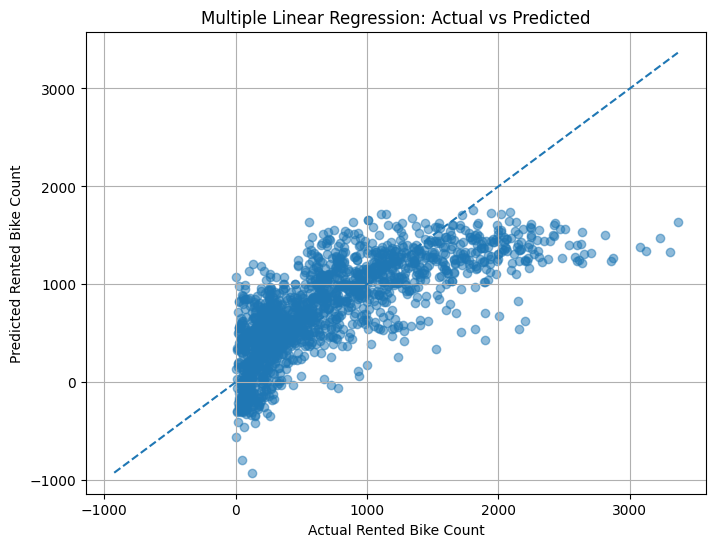

In [49]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_mlr,
    alpha=0.5
)

min_value = min(y_test.min(), y_pred_mlr.min())
max_value = max(y_test.max(), y_pred_mlr.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Rented Bike Count')
plt.ylabel('Predicted Rented Bike Count')
plt.title('Multiple Linear Regression: Actual vs Predicted')

plt.grid()
plt.show()

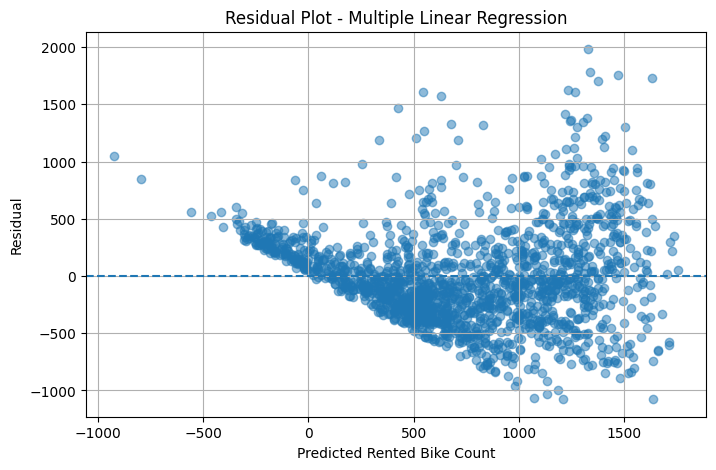

In [50]:
residuals_mlr = y_test - y_pred_mlr

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_mlr,
    residuals_mlr,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Rented Bike Count')
plt.ylabel('Residual')
plt.title('Residual Plot - Multiple Linear Regression')

plt.grid()
plt.show()

Polynomial Regression


In [52]:
X = df[['Temperature(°C)']]
y = df['Rented Bike Count']

print(X.head())
print(y.head())

   Temperature(°C)
0             -5.2
1             -5.5
2             -6.0
3             -6.2
4             -6.0
0    254
1    204
2    173
3    107
4     78
Name: Rented Bike Count, dtype: int64


In [53]:
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Missing values in X:
Temperature(°C)    0
dtype: int64

Missing values in y:
0


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7008, 1)
Testing data: (1752, 1)


In [55]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [56]:
print(X_train_poly[:5])

[[  1.    13.2  174.24]
 [  1.    22.9  524.41]
 [  1.    11.2  125.44]
 [  1.    -2.6    6.76]
 [  1.    27.2  739.84]]


In [57]:
model = LinearRegression()

In [58]:
model.fit(X_train_poly, y_train)

LinearRegression()

In [59]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 327.94708235703615
Coefficients: [0.00000000e+00 2.88066874e+01 1.37183198e-02]


In [60]:
print("Intercept:", model.intercept_)
print("Temperature coefficient:", model.coef_[1])
print("Temperature² coefficient:", model.coef_[2])

Intercept: 327.94708235703615
Temperature coefficient: 28.80668738703054
Temperature² coefficient: 0.013718319758254438


In [61]:
y_pred_poly = model.predict(X_test_poly)

In [62]:
comparison_poly = pd.DataFrame({
    'Temperature': X_test['Temperature(°C)'].values,
    'Actual Bike Count': y_test.values,
    'Predicted Bike Count': y_pred_poly
})

comparison_poly.head(10)

,Temperature,Actual Bike Count,Predicted Bike Count
0,27.2,1728,1121.638341
1,32.6,822,1281.624373
2,34.0,658,1323.232831
3,16.9,2716,818.698189
4,6.4,1083,512.871784
5,28.0,636,1145.289492
6,31.3,1537,1243.036098
7,2.1,712,388.501624
8,26.7,425,1106.865289
9,16.6,594,809.918313


In [63]:
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression")
print("---------------------")
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE:", rmse_poly)
print("R²  :", r2_poly)

Polynomial Regression
---------------------
MAE : 402.636979131865
MSE : 293128.480499738
RMSE: 541.4134099740586
R²  : 0.29645715244676085


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


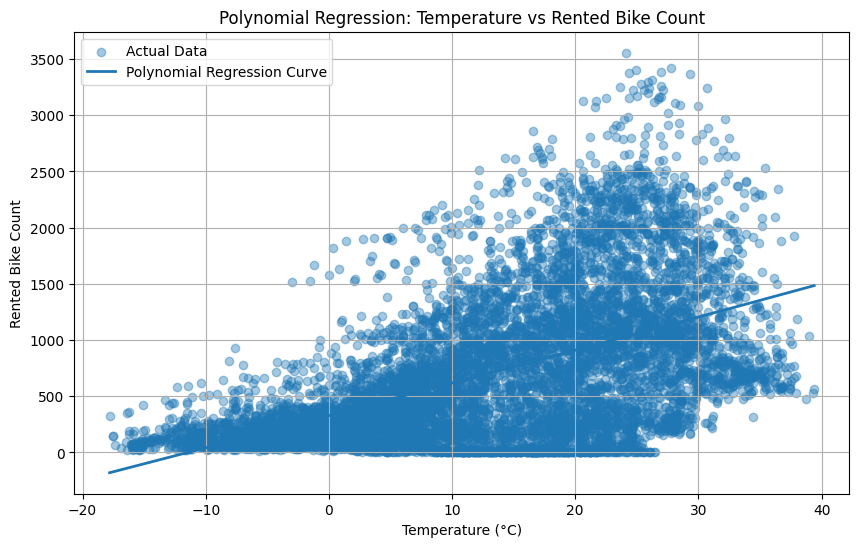

In [64]:
X_curve = np.linspace(
    X['Temperature(°C)'].min(),
    X['Temperature(°C)'].max(),
    300
).reshape(-1, 1)

X_curve_poly = poly.transform(X_curve)

y_curve = model.predict(X_curve_poly)

plt.figure(figsize=(10, 6))

plt.scatter(
    X['Temperature(°C)'],
    y,
    alpha=0.4,
    label='Actual Data'
)

plt.plot(
    X_curve,
    y_curve,
    linewidth=2,
    label='Polynomial Regression Curve'
)

plt.xlabel('Temperature (°C)')
plt.ylabel('Rented Bike Count')
plt.title('Polynomial Regression: Temperature vs Rented Bike Count')
plt.legend()
plt.grid(True)

plt.show()

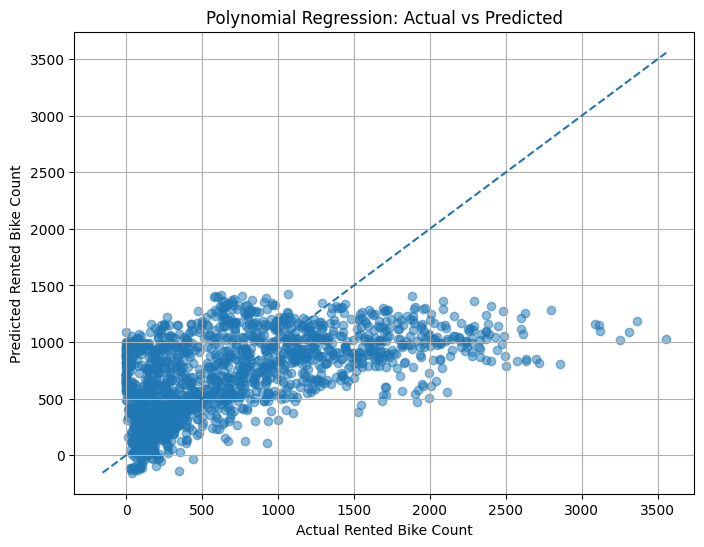

In [65]:
#Actual vs Predicted graph
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_poly,
    alpha=0.5
)

min_value = min(y_test.min(), y_pred_poly.min())
max_value = max(y_test.max(), y_pred_poly.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Rented Bike Count')
plt.ylabel('Predicted Rented Bike Count')
plt.title('Polynomial Regression: Actual vs Predicted')

plt.grid(True)
plt.show()

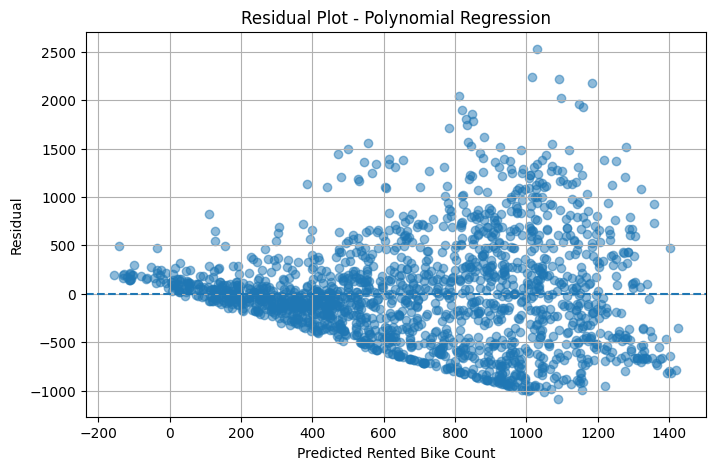

In [66]:
#Residual Plot
residuals_poly = y_test - y_pred_poly

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_poly,
    residuals_poly,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Rented Bike Count')
plt.ylabel('Residual')
plt.title('Residual Plot - Polynomial Regression')

plt.grid(True)
plt.show()